# 2. Graphical Monitoring and Overfitting

First, we import the necessary libraries and load the **large version** of the California housing dataset.  
The data is initially split into a training set and a test set.

In [141]:
import numpy as np
import matplotlib.pyplot as plt

from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from keras.datasets import california_housing
from keras.callbacks import EarlyStopping
from keras.regularizers import l2

(inputs, targets), (x_test, y_test) = california_housing.load_data(version='large', test_split=0.2)
print(inputs.shape, x_test.shape)
print(x_test.shape, y_test.shape)

(16512, 8) (4128, 8)
(4128, 8) (4128,)


## Creating a Validation Set

To monitor the model during training and adjust hyperparameters, we set aside a validation set.  
Here, the last 20% of the training data is used for validation, and the remaining 80% is used for training.

In [142]:
num_val_samples = int(0.2 * inputs.shape[0])

x_val = inputs[:num_val_samples]
y_val = targets[:num_val_samples]

x_train = inputs[num_val_samples:]
y_train = targets[num_val_samples:]

## Data Preprocessing

Neural networks work better when input features have similar scale.  
Here, the features are standardized using the mean and standard deviation from the training set.  

The target house prices are also scaled down by dividing by 100,000 to make training more stable and the loss values easier to read.

In [143]:
# Normalize inputs
mean = x_train.mean(axis=0)
std = x_train.std(axis=0)

x_train = (x_train - mean) / std
x_val = (x_val - mean) / std
x_test = (x_test - mean) / std

# Scale targets
y_train = y_train / 1e5
y_val = y_val / 1e5
y_test = y_test / 1e5

## Baseline Model Construction

To see overfitting, a relatively large fully connected neural network is built with three hidden layers (128, 128, and 64 neurons) and **no regularization**.  
This setup lets the model memorize the training data, which can be checked with the validation set.

In [144]:
model = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

## Training the Baseline Model

The baseline model is trained for **500 epochs**.  
The output during training is suppressed to keep the notebook clean, and the `history` object is used to store the training and validation metrics for later plotting.

In [145]:
history = model.fit(
    x_train, 
    y_train, 
    epochs=500, 
    batch_size=32, 
    validation_data=(x_val, y_val), 
    verbose=0
)

## Graphical Monitoring

The plots below show how the model is performing on the training and validation sets.

We can see that the **training loss and MAE keep decreasing**, but the **validation loss and MAE stop improving and may start to rise** after some epochs. This clearly shows that the model is overfitting the training data.

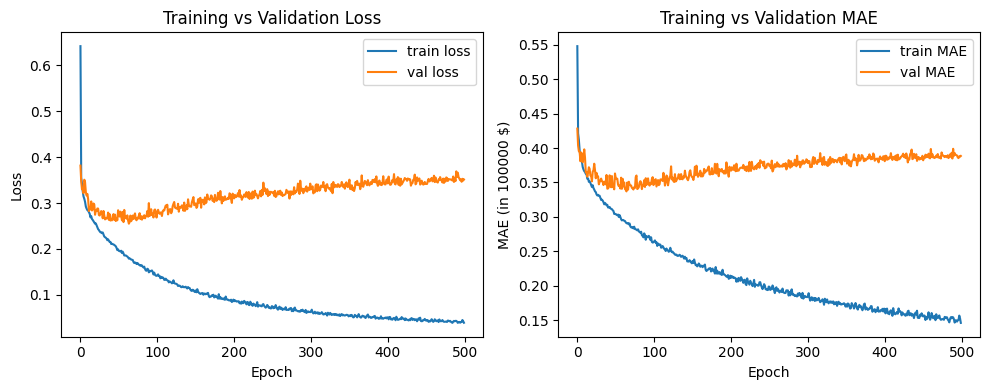

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')

# Plot training and validation MAE
plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='train MAE')
plt.plot(history.history['val_mae'], label='val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE (in 100000 $)')
plt.legend()
plt.title('Training vs Validation MAE')

plt.tight_layout()
plt.show()

## 6. Reducing Overfitting

To make the model generalize better and avoid memorizing the training data, I used two techniques. First, **Dropout** randomly turns off 30% of the neurons during training, forcing the network to learn patterns that apply to more than just the training examples. Second, **Early Stopping** monitors the validation MAE and stops training if it does not improve for 10 consecutive epochs, automatically keeping the best model.

In [ ]:
model_reg = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1)
])

model_reg.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(
    monitor='val_mae',
    patience=10,
    restore_best_weights=True
)

history_reg = model_reg.fit(
    x_train, y_train,
    epochs=500,
    batch_size=32,
    validation_data=(x_val, y_val),
    callbacks=[early_stop],
    verbose=0
)

## Final Model Training
Now that we have found an architecture that handles overfitting much better, it is time to train the final model. 

To maximize the learning potential, I am concatenating the training and validation sets back into a single, larger dataset (`x_full` and `y_full`). The final model uses the exact same architecture (with Dropout) and is trained for a fixed 100 epochs, which is a safe estimate based on the Early Stopping behavior from the previous step.

In [146]:
# Combine training + validation sets
x_full = np.concatenate([x_train, x_val])
y_full = np.concatenate([y_train, y_val])

final_model = Sequential([
    Input(shape=(x_full.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1)
])

final_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

final_model.fit(
    x_full, y_full,
    epochs=100,
    batch_size=32,
    verbose=0
)

## Final Evaluation on Test Set

Finally, we check how well the model performs on the unseen test set. The Test MAE shows how accurate the model is at predicting median house prices in California for new data.

In [148]:
test_loss, test_mae = final_model.evaluate(x_test, y_test)
print(f"Final model Test MAE: {test_mae}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2763 - mae: 0.3495
Final model Test MAE: 0.3494936525821686
